## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import openpyxl
from pathlib import Path

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Data

In [44]:
# Current working directory (where notebook runs)
current_path = Path().resolve()

# Go up manually depending on where you are
project_root = current_path.parent.parent   # adjust if needed

BDCOM_file = project_root / "data" / "bronze" / "public_service_data" / "BDCOM_2023.csv"
BDCOM_file_old =  project_root / "data" / "bronze" / "public_service_data" / "BDCOM_2023_OD.xlsx"

output_path = project_root / "data" / "silver"
# Load CSV file
df_bdcom = pd.read_csv(BDCOM_file)

# Load Excel file
df_od = pd.read_excel(BDCOM_file_old)

print("BDCOM_2023.csv shape:", df_bdcom.shape)
print("BDCOM_2023_OD.xlsx shape:", df_od.shape)

BDCOM_2023.csv shape: (60845, 25)
BDCOM_2023_OD.xlsx shape: (224, 12)


## 3. Initial Data Inspection

In [8]:
# Display first few rows of BDCOM data

print("BDCOM_2023.csv - First 5 rows")

display(df_bdcom.head())

BDCOM_2023.csv - First 5 rows


,X,Y,OBJECTID,c_ord,arro,qua,xbis,ybis,num,let,typ_voie,lib_voie,seq,sit,type,codact,ens,bio,surf,cc_id,cc_niv,niv47,niv18,niv8,niv2
0,651791.0486,6.862992e+06,1,1311,1,2,651792.345590,6.862996e+06,25,NaN,RUE,LOUVRE,2,A,C,CB107,Y'S,0.0,1,0.0,NaN,10301,103,3,1
1,652152.0612,6.862579e+06,2,1464,1,2,652152.061200,6.862579e+06,1,NaN,RUE,PIERRE LESCOT,118,CC,C,CC301,ALAIN AFFLELOU,0.0,1,1.0,-3.0,10403,104,3,1
2,651430.1357,6.862714e+06,4,1623,1,3,651430.135700,6.862714e+06,196,NaN,RUE,SAINT HONORE,1,R,C,CH106,ENZA FAMIGLIA,0.0,1,0.0,NaN,11101,111,5,1
3,651133.4910,6.862932e+06,6,2087,1,3,651130.053214,6.862939e+06,7,NaN,RUE,ARGENTEUIL,3,R,C,SA202,JULIE BEAUTE,0.0,1,0.0,NaN,10802,108,4,1
4,651124.6132,6.863066e+06,7,2157,1,3,651124.613200,6.863066e+06,20,NaN,RUE,PYRAMIDES,1,A,C,CD201,HOME AUTOUR DU MONDE,0.0,1,0.0,NaN,10502,105,3,1


In [9]:
# Display first few rows of OD data
print("BDCOM_2023_OD.xlsx - First 5 rows")
display(df_od.head())

BDCOM_2023_OD.xlsx - First 5 rows


,Code activité (224 postes),Libellé activité (224 postes),TYPE,Libellé TYPE (local),Code activité 47 postes,Libellé activité 47 postes,Code activité 18 postes,Libellé activité 18 postes,Code activité 8 postes,Libellé activité 8 postes),Code activité 2 postes,Libellé activité 2 postes
0,AA101,Local vacant,V,Local vacant,21301,Local vacant,213,Local vacant,6,Local vacant,2.0,Autre local en rez-de-chaussée
1,AA102,Local en travaux,V,Local vacant,21301,Local vacant,213,Local vacant,6,Autre local,2.0,Autre local en rez-de-chaussée
2,AB101,Commerce de gros alimentaire,T,Commerce de gros,21401,Commerce de gros,214,Commerce de gros,7,Autre local,2.0,Autre local en rez-de-chaussée
3,AB102,Commerce de gros fabrication textile,T,Commerce de gros,21401,Commerce de gros,214,Commerce de gros,7,Autre local,2.0,Autre local en rez-de-chaussée
4,AB103,Commerce de gros fabrication habillement,T,Commerce de gros,21401,Commerce de gros,214,Commerce de gros,7,Autre local,2.0,Autre local en rez-de-chaussée


In [10]:
# Basic info about BDCOM data
print("BDCOM_2023.csv - Data Info")
df_bdcom.info()

BDCOM_2023.csv - Data Info
<class 'pandas.DataFrame'>
RangeIndex: 60845 entries, 0 to 60844
Data columns (total 25 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   X         60845 non-null  float64
 1   Y         60845 non-null  float64
 2   OBJECTID  60845 non-null  int64  
 3   c_ord     60845 non-null  int64  
 4   arro      60845 non-null  int64  
 5   qua       60845 non-null  int64  
 6   xbis      60845 non-null  float64
 7   ybis      60845 non-null  float64
 8   num       60845 non-null  int64  
 9   let       1917 non-null   str    
 10  typ_voie  60845 non-null  str    
 11  lib_voie  60845 non-null  str    
 12  seq       60845 non-null  int64  
 13  sit       60845 non-null  str    
 14  type      60845 non-null  str    
 15  codact    60845 non-null  str    
 16  ens       60844 non-null  str    
 17  bio       60693 non-null  float64
 18  surf      60845 non-null  int64  
 19  cc_id     60698 non-null  float64
 20  cc_niv    20

In [11]:
# Basic info about OD data
print("BDCOM_2023_OD.xlsx - Data Info")
df_od.info()

BDCOM_2023_OD.xlsx - Data Info
<class 'pandas.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Code activité (224 postes)     224 non-null    str    
 1   Libellé activité (224 postes)  224 non-null    str    
 2   TYPE                           224 non-null    str    
 3   Libellé TYPE (local)           224 non-null    str    
 4   Code activité 47 postes        224 non-null    int64  
 5   Libellé activité 47 postes     224 non-null    str    
 6   Code activité 18 postes        224 non-null    int64  
 7   Libellé activité 18 postes     224 non-null    str    
 8   Code activité 8 postes         224 non-null    int64  
 9   Libellé activité 8 postes)     223 non-null    str    
 10  Code activité 2 postes         223 non-null    float64
 11  Libellé activité 2 postes      223 non-null    str    
dtypes: float64(1), int64(3), str(8

## 4. Data Merging

Merge the two datasets based on the activity code field (`codact` from BDCOM matches with activity code from OD)

In [12]:
# Rename the first column of df_od to match for merging
# The column "Code activité (224 postes)" should match with "codact" from df_bdcom
df_od_clean = df_od.rename(columns={'Code activité (224 postes)': 'codact'})

print("Columns in df_od after renaming:")
print(df_od_clean.columns.tolist())

Columns in df_od after renaming:
['codact', 'Libellé activité (224 postes)', 'TYPE', 'Libellé TYPE (local)', 'Code activité 47 postes', 'Libellé activité 47 postes', 'Code activité 18 postes', 'Libellé activité 18 postes', 'Code activité 8 postes', 'Libellé activité 8 postes)', 'Code activité 2 postes', 'Libellé activité 2 postes']


In [13]:
# Check unique values in merge key
print(f"Unique codact values in BDCOM: {df_bdcom['codact'].nunique()}")
print(f"Unique codact values in OD: {df_od_clean['codact'].nunique()}")

# Sample values
print("\nSample codact from BDCOM:")
print(df_bdcom['codact'].unique()[:10])
print("\nSample codact from OD:")
print(df_od_clean['codact'].unique()[:10])

Unique codact values in BDCOM: 194
Unique codact values in OD: 224

Sample codact from BDCOM:
<StringArray>
['CB107', 'CC301', 'CH106', 'SA202', 'CD201', 'CB202', 'SA102', 'CB105',
 'CH103', 'CB104']
Length: 10, dtype: str

Sample codact from OD:
<StringArray>
['AA101', 'AA102', 'AB101', 'AB102', 'AB103', 'AB104', 'AB105', 'AB106',
 'AC101', 'AC102']
Length: 10, dtype: str


In [14]:
# Perform the merge
df_merged = pd.merge(
    df_bdcom,
    df_od_clean,
    on='codact',
    how='left',  # Keep all BDCOM records
    indicator=True  # Add merge indicator
)

print(f"Merged dataset shape: {df_merged.shape}")
print(f"\nMerge statistics:")
print(df_merged['_merge'].value_counts())

Merged dataset shape: (60845, 37)

Merge statistics:
_merge
both          60845
left_only         0
right_only        0
Name: count, dtype: int64


In [15]:
# Display merged data sample

print("Merged Dataset - First 5 rows")

display(df_merged.head())

Merged Dataset - First 5 rows


,X,Y,OBJECTID,c_ord,arro,qua,xbis,ybis,num,let,typ_voie,lib_voie,seq,sit,type,codact,ens,bio,surf,cc_id,cc_niv,niv47,niv18,niv8,niv2,Libellé activité (224 postes),TYPE,Libellé TYPE (local),Code activité 47 postes,Libellé activité 47 postes,Code activité 18 postes,Libellé activité 18 postes,Code activité 8 postes,Libellé activité 8 postes),Code activité 2 postes,Libellé activité 2 postes,_merge
0,651791.0486,6.862992e+06,1,1311,1,2,651792.345590,6.862996e+06,25,NaN,RUE,LOUVRE,2,A,C,CB107,Y'S,0.0,1,0.0,NaN,10301,103,3,1,Prêt-à-porter Mixte,C,Commerce,10301,Habillement,103,Equipement de la personne,3,Non Alimentaire,1.0,Commerce et service commercial,both
1,652152.0612,6.862579e+06,2,1464,1,2,652152.061200,6.862579e+06,1,NaN,RUE,PIERRE LESCOT,118,CC,C,CC301,ALAIN AFFLELOU,0.0,1,1.0,-3.0,10403,104,3,1,Opticien,C,Commerce,10403,Opticien,104,Santé-Beauté,3,Non Alimentaire,1.0,Commerce et service commercial,both
2,651430.1357,6.862714e+06,4,1623,1,3,651430.135700,6.862714e+06,196,NaN,RUE,SAINT HONORE,1,R,C,CH106,ENZA FAMIGLIA,0.0,1,0.0,NaN,11101,111,5,1,Restaurant européen,C,Commerce,11101,Restauration traditionnelle,111,Café et Restaurant,5,Restauration,1.0,Commerce et service commercial,both
3,651133.4910,6.862932e+06,6,2087,1,3,651130.053214,6.862939e+06,7,NaN,RUE,ARGENTEUIL,3,R,C,SA202,JULIE BEAUTE,0.0,1,0.0,NaN,10802,108,4,1,Institut de beauté - Activités thermales et th...,C,Commerce,10802,Soins du corps,108,Service aux particuliers,4,Service commercial,1.0,Commerce et service commercial,both
4,651124.6132,6.863066e+06,7,2157,1,3,651124.613200,6.863066e+06,20,NaN,RUE,PYRAMIDES,1,A,C,CD201,HOME AUTOUR DU MONDE,0.0,1,0.0,NaN,10502,105,3,1,Equipement du foyer généraliste,C,Commerce,10502,Petit équipement du foyer,105,Equipement de la maison,3,Non Alimentaire,1.0,Commerce et service commercial,both


## 5. Exploratory Data Analysis (EDA)

### 5.1 Dataset Overview

In [16]:

print("DATASET OVERVIEW")

print(f"Total Rows: {df_merged.shape[0]:,}")
print(f"Total Columns: {df_merged.shape[1]}")
print(f"\nMemory Usage: {df_merged.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET OVERVIEW
Total Rows: 60,845
Total Columns: 37

Memory Usage: 59.37 MB


In [17]:
# Column names and data types
print("\nColumns and Data Types:")
print("-" * 80)
for col, dtype in df_merged.dtypes.items():
    print(f"{col:<40} {str(dtype):<20}")


Columns and Data Types:
--------------------------------------------------------------------------------
X                                        float64             
Y                                        float64             
OBJECTID                                 int64               
c_ord                                    int64               
arro                                     int64               
qua                                      int64               
xbis                                     float64             
ybis                                     float64             
num                                      int64               
let                                      str                 
typ_voie                                 str                 
lib_voie                                 str                 
seq                                      int64               
sit                                      str                 
type                      

### 5.2 Missing Values Analysis

In [18]:
# Missing values count and percentage
missing_data = pd.DataFrame({
    'Column': df_merged.columns,
    'Missing_Count': df_merged.isnull().sum(),
    'Missing_Percentage': (df_merged.isnull().sum() / len(df_merged) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)


print("MISSING VALUES ANALYSIS")

display(missing_data[missing_data['Missing_Count'] > 0])

MISSING VALUES ANALYSIS


,Column,Missing_Count,Missing_Percentage
let,let,58928,96.85
cc_niv,cc_niv,58790,96.62
bio,bio,152,0.25
cc_id,cc_id,147,0.24
ens,ens,1,0.00


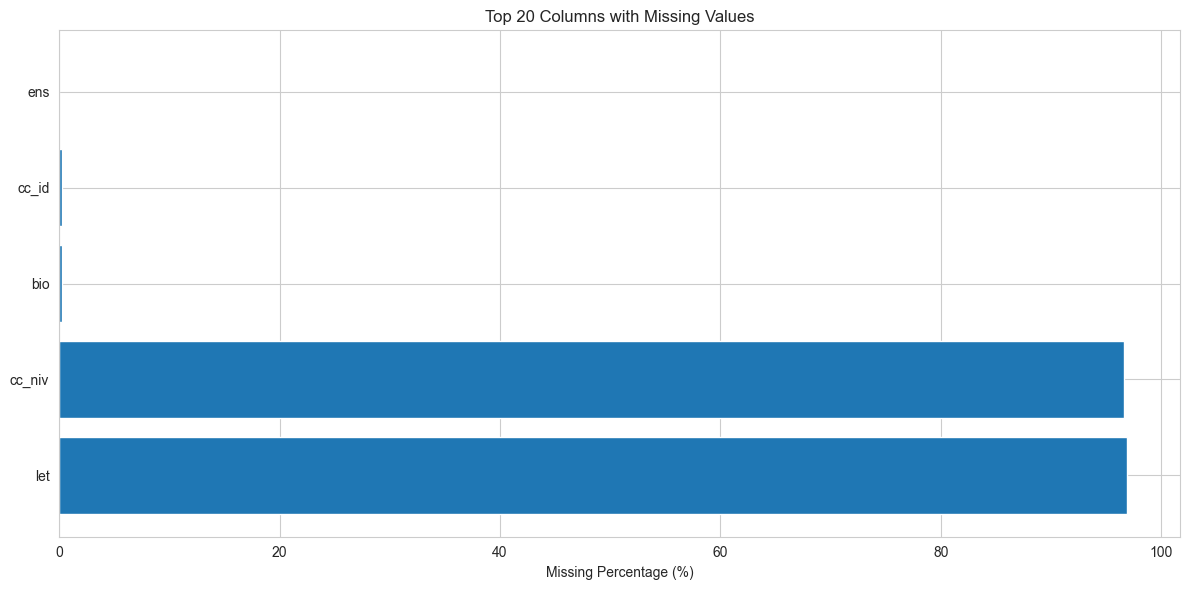

In [19]:
# Visualize missing values
missing_cols = missing_data[missing_data['Missing_Count'] > 0]['Column'].tolist()

if len(missing_cols) > 0:
    plt.figure(figsize=(12, 6))
    missing_plot_data = missing_data[missing_data['Missing_Count'] > 0].head(20)
    plt.barh(missing_plot_data['Column'], missing_plot_data['Missing_Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Top 20 Columns with Missing Values')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found!")

### 5.3 Statistical Summary

In [20]:
# Numeric columns summary

print("NUMERICAL FEATURES SUMMARY")

display(df_merged.describe())

NUMERICAL FEATURES SUMMARY


,X,Y,OBJECTID,c_ord,arro,qua,xbis,ybis,num,seq,bio,surf,cc_id,cc_niv,niv47,niv18,niv8,niv2,Code activité 47 postes,Code activité 18 postes,Code activité 8 postes,Code activité 2 postes
count,60845.000000,6.084500e+04,60845.000000,60845.000000,60845.000000,60845.000000,60845.000000,6.084500e+04,60845.000000,60845.000000,60693.000000,60845.000000,60698.000000,2055.000000,60845.000000,60845.000000,60845.000000,60845.0,60845.000000,60845.000000,60845.000000,60845.000000
mean,651681.811849,6.862649e+06,41952.515293,46949.584962,11.435122,44.210880,651681.755204,6.862649e+06,55.127981,2.456521,0.008535,1.072874,4.335332,-0.082725,10714.421579,107.123313,3.802022,1.0,10714.421579,107.123313,3.802022,1.006673
std,2408.204409,2.006038e+03,24177.182300,27412.820093,5.400627,21.572321,2408.188700,2.005988e+03,60.002350,7.417936,0.091989,0.324803,36.769570,0.921436,334.384926,3.341905,1.250791,0.0,334.384926,3.341905,1.250791,0.081414
min,643570.954900,6.857578e+06,1.000000,2.000000,1.000000,1.000000,643570.954900,6.857578e+06,0.000000,0.000000,0.000000,1.000000,0.000000,-4.000000,10101.000000,101.000000,1.000000,1.0,10101.000000,101.000000,1.000000,1.000000
25%,650153.038300,6.861168e+06,20944.000000,23021.000000,7.000000,28.000000,650153.038300,6.861166e+06,13.000000,1.000000,0.000000,1.000000,0.000000,0.000000,10401.000000,104.000000,3.000000,1.0,10401.000000,104.000000,3.000000,1.000000
50%,651819.881300,6.862736e+06,41997.000000,46562.000000,12.000000,45.000000,651821.065907,6.862736e+06,34.000000,1.000000,0.000000,1.000000,0.000000,0.000000,10802.000000,108.000000,4.000000,1.0,10802.000000,108.000000,4.000000,1.000000
75%,653361.228900,6.864219e+06,62927.000000,69523.000000,16.000000,63.000000,653361.450877,6.864219e+06,77.000000,2.000000,0.000000,1.000000,0.000000,0.000000,11101.000000,111.000000,5.000000,1.0,11101.000000,111.000000,5.000000,1.000000
max,660318.425600,6.867030e+06,83150.000000,100076.000000,20.000000,80.000000,660318.425600,6.867030e+06,422.000000,146.000000,1.000000,3.000000,750.000000,3.000000,11203.000000,112.000000,8.000000,1.0,11203.000000,112.000000,8.000000,2.000000


In [21]:
# Categorical columns summary
categorical_cols = df_merged.select_dtypes(include=['object']).columns


print("CATEGORICAL FEATURES SUMMARY")

for col in categorical_cols[:10]:  # Show first 10 categorical columns
    print(f"\n{col}:")
    print(f"\tUnique values: {df_merged[col].nunique()}")
    print(f"\tTop 5 values:")
    print(df_merged[col].value_counts().head())

CATEGORICAL FEATURES SUMMARY

let:
	Unique values: 8
	Top 5 values:
let
B    1759
T     120
W      11
V      10
Q       7
Name: count, dtype: int64

typ_voie:
	Unique values: 23
	Top 5 values:
typ_voie
RUE    45053
AV      6801
BD      6586
PL      1323
QU       359
Name: count, dtype: int64

lib_voie:
	Unique values: 2905
	Top 5 values:
lib_voie
CLICHY        516
VAUGIRARD     454
VOLTAIRE      440
BELLEVILLE    401
PYRENEES      376
Name: count, dtype: int64

sit:
	Unique values: 4
	Top 5 values:
sit
R     48822
A      9302
CC     2024
CI      697
Name: count, dtype: int64

type:
	Unique values: 3
	Top 5 values:
type
C    60439
K      368
D       38
Name: count, dtype: int64

codact:
	Unique values: 194
	Top 5 values:
codact
CH303    2956
CH201    2670
SA201    2658
CH103    1978
CH101    1876
Name: count, dtype: int64

ens:
	Unique values: 43015
	Top 5 values:
ens
*** NON RENSEIGNE ***    1686
(KIOSQUE A JOURNAUX)      323
FRANPRIX                  305
NICOLAS                   156


### 5.4 Duplicate Analysis

In [22]:
# Check for duplicates
duplicates = df_merged.duplicated().sum()

print("DUPLICATE ANALYSIS")

print(f"Total duplicate rows: {duplicates:,}")
print(f"Percentage: {(duplicates/len(df_merged)*100):.2f}%")

# Check for duplicates based on OBJECTID (should be unique)
if 'OBJECTID' in df_merged.columns:
    objectid_dupes = df_merged['OBJECTID'].duplicated().sum()
    print(f"\nDuplicate OBJECTID values: {objectid_dupes}")

DUPLICATE ANALYSIS
Total duplicate rows: 0
Percentage: 0.00%

Duplicate OBJECTID values: 0


### 5.5 Key Variables Distribution

DISTRIBUTION OF LOCAL TYPES
TYPE
C    60439
K      368
D       38
Name: count, dtype: int64


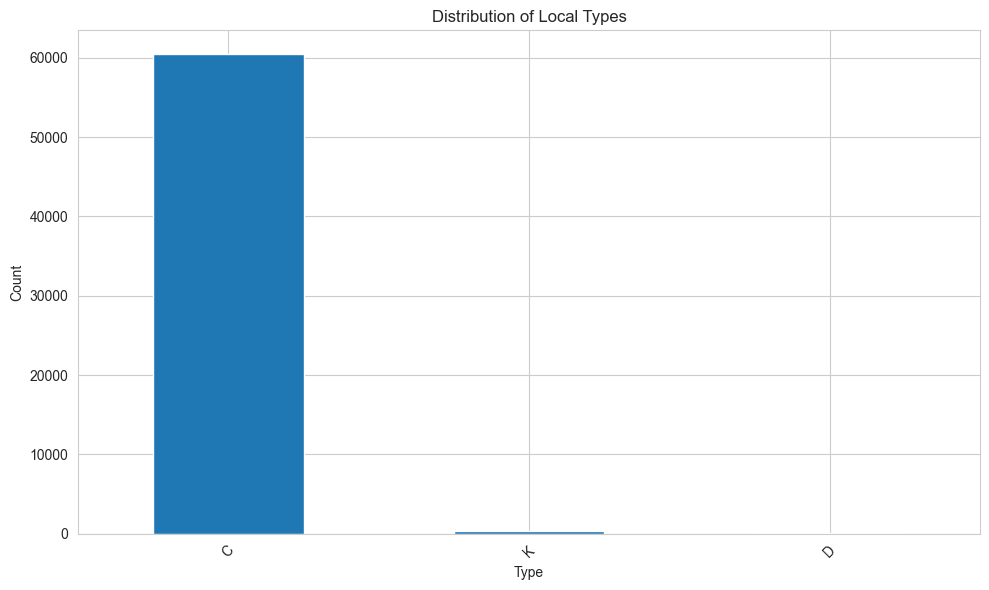

In [23]:
# Distribution of activity types
if 'TYPE' in df_merged.columns:
    
    print("DISTRIBUTION OF LOCAL TYPES")
    
    print(df_merged['TYPE'].value_counts())
    
    plt.figure(figsize=(10, 6))
    df_merged['TYPE'].value_counts().plot(kind='bar')
    plt.title('Distribution of Local Types')
    plt.xlabel('Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

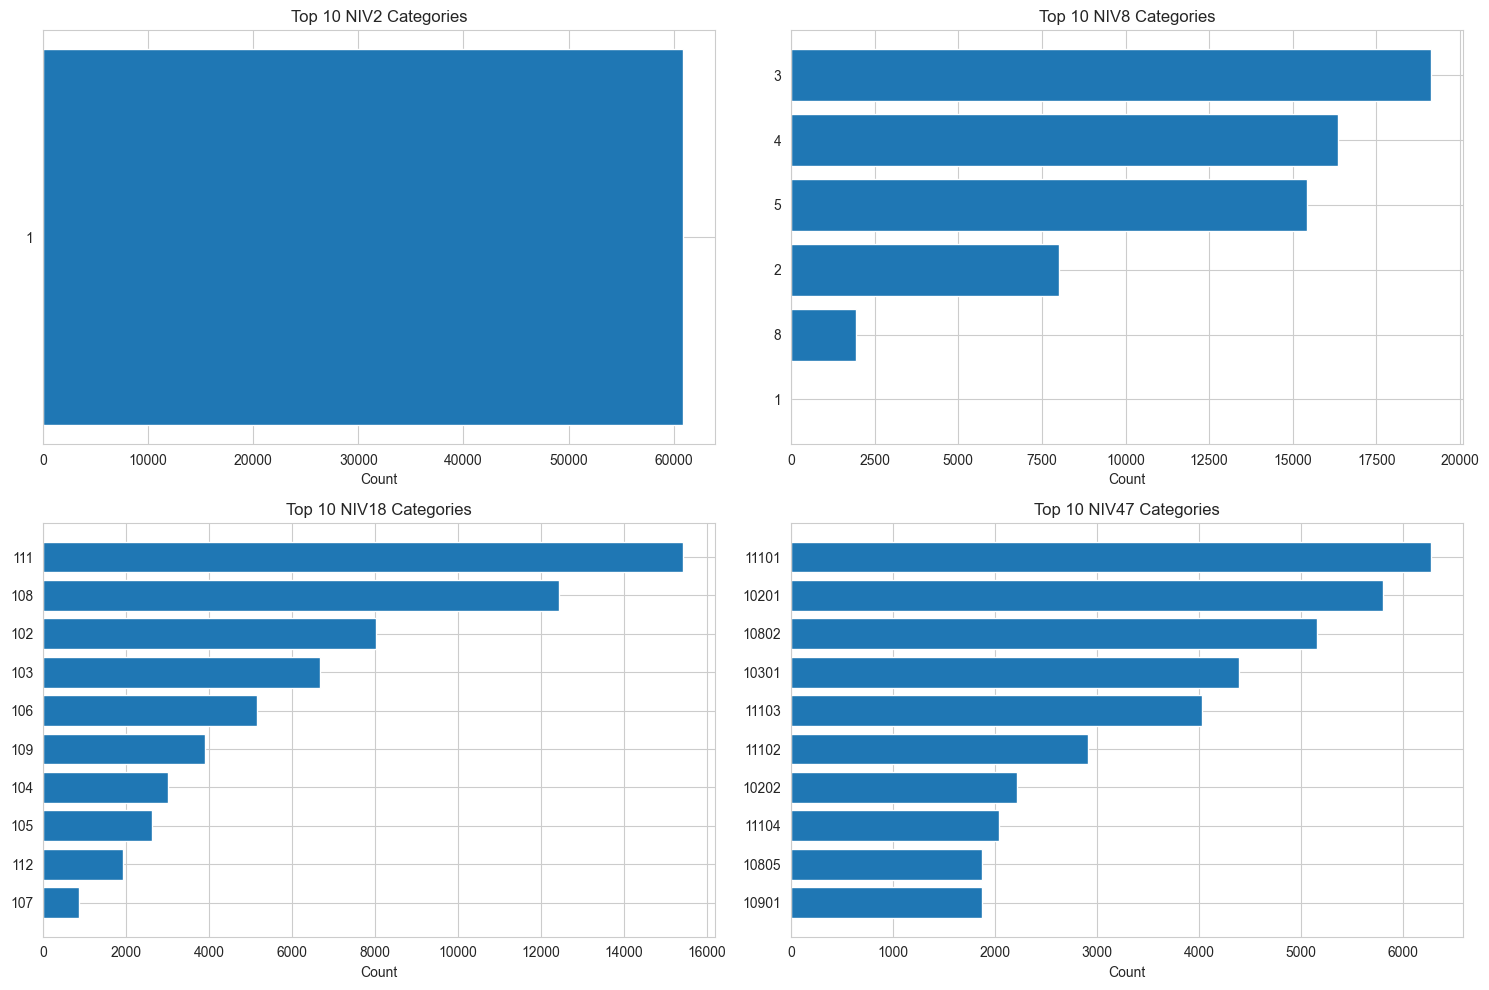

In [24]:
# Distribution by activity levels (niv2, niv8, niv18, niv47)
activity_levels = ['niv2', 'niv8', 'niv18', 'niv47']
existing_levels = [col for col in activity_levels if col in df_merged.columns]

if existing_levels:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(existing_levels):
        top_values = df_merged[col].value_counts().head(10)
        axes[idx].barh(range(len(top_values)), top_values.values)
        axes[idx].set_yticks(range(len(top_values)))
        axes[idx].set_yticklabels(top_values.index)
        axes[idx].set_xlabel('Count')
        axes[idx].set_title(f'Top 10 {col.upper()} Categories')
        axes[idx].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

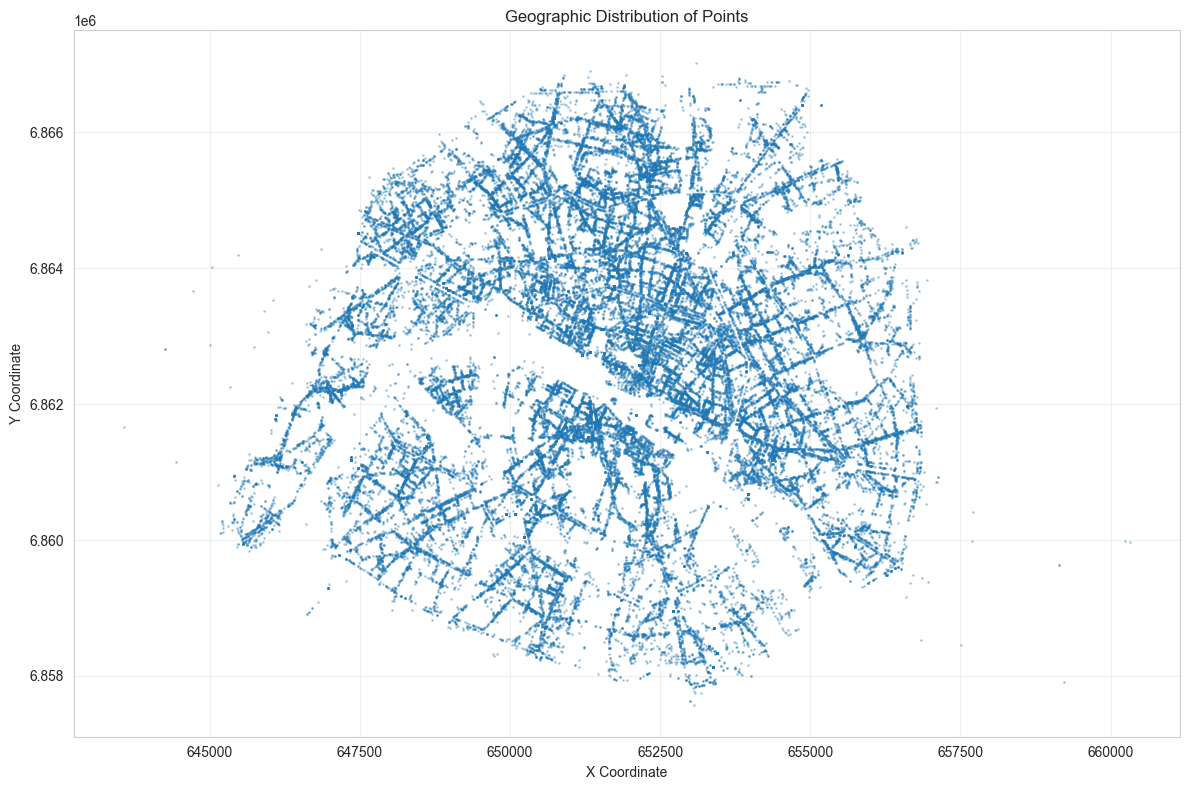

In [25]:
# Geographic distribution (X, Y coordinates)
if 'X' in df_merged.columns and 'Y' in df_merged.columns:
    plt.figure(figsize=(12, 8))
    plt.scatter(df_merged['X'], df_merged['Y'], alpha=0.3, s=1)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('Geographic Distribution of Points')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

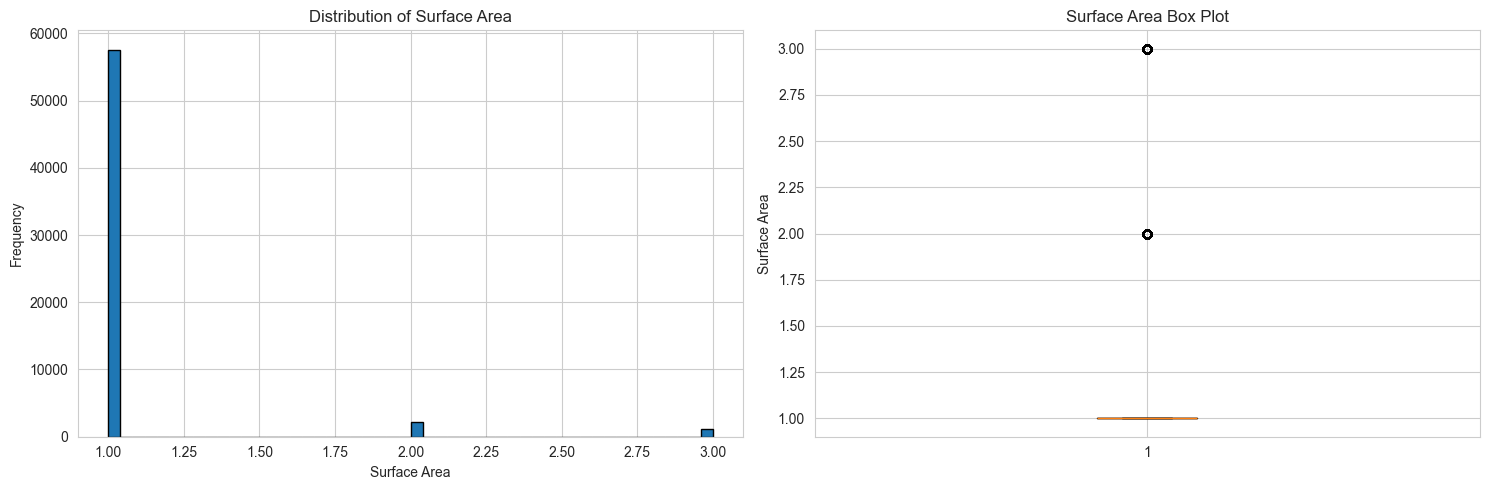


Surface Area Statistics:
count    60845.000000
mean         1.072874
std          0.324803
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: surf, dtype: float64


In [26]:
# Surface area distribution
if 'surf' in df_merged.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histogram
    axes[0].hist(df_merged['surf'].dropna(), bins=50, edgecolor='black')
    axes[0].set_xlabel('Surface Area')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Surface Area')
    
    # Box plot
    axes[1].boxplot(df_merged['surf'].dropna())
    axes[1].set_ylabel('Surface Area')
    axes[1].set_title('Surface Area Box Plot')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSurface Area Statistics:")
    print(df_merged['surf'].describe())

TOP 20 ESTABLISHMENTS


,Establishment,Count
0,*** NON RENSEIGNE ***,1686
1,(KIOSQUE A JOURNAUX),323
2,FRANPRIX,305
3,NICOLAS,156
4,CARREFOUR CITY,144
5,LA POSTE,141
6,BNP PARIBAS,140
7,SOCIETE GENERALE,138
8,LCL,136
9,PICARD,121


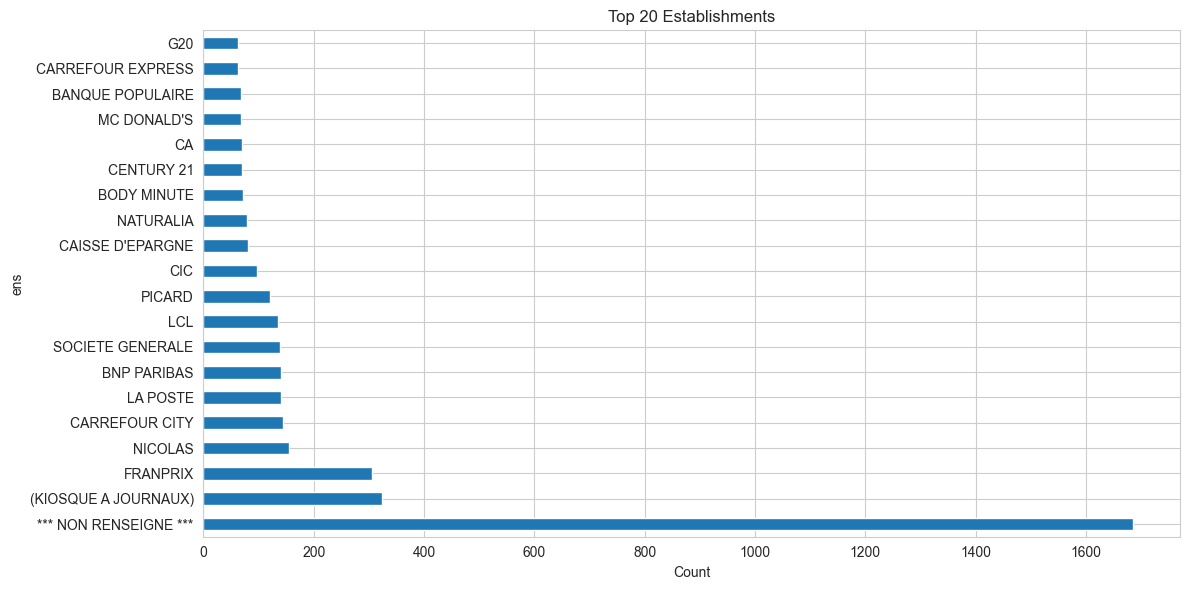

In [27]:
# Top establishments (ens)
if 'ens' in df_merged.columns:
    
    print("TOP 20 ESTABLISHMENTS")
    
    top_ens = df_merged['ens'].value_counts().head(20)
    display(pd.DataFrame({'Establishment': top_ens.index, 'Count': top_ens.values}))
    
    plt.figure(figsize=(12, 6))
    top_ens.plot(kind='barh')
    plt.xlabel('Count')
    plt.title('Top 20 Establishments')
    plt.tight_layout()
    plt.show()

### 5.6 Correlation Analysis

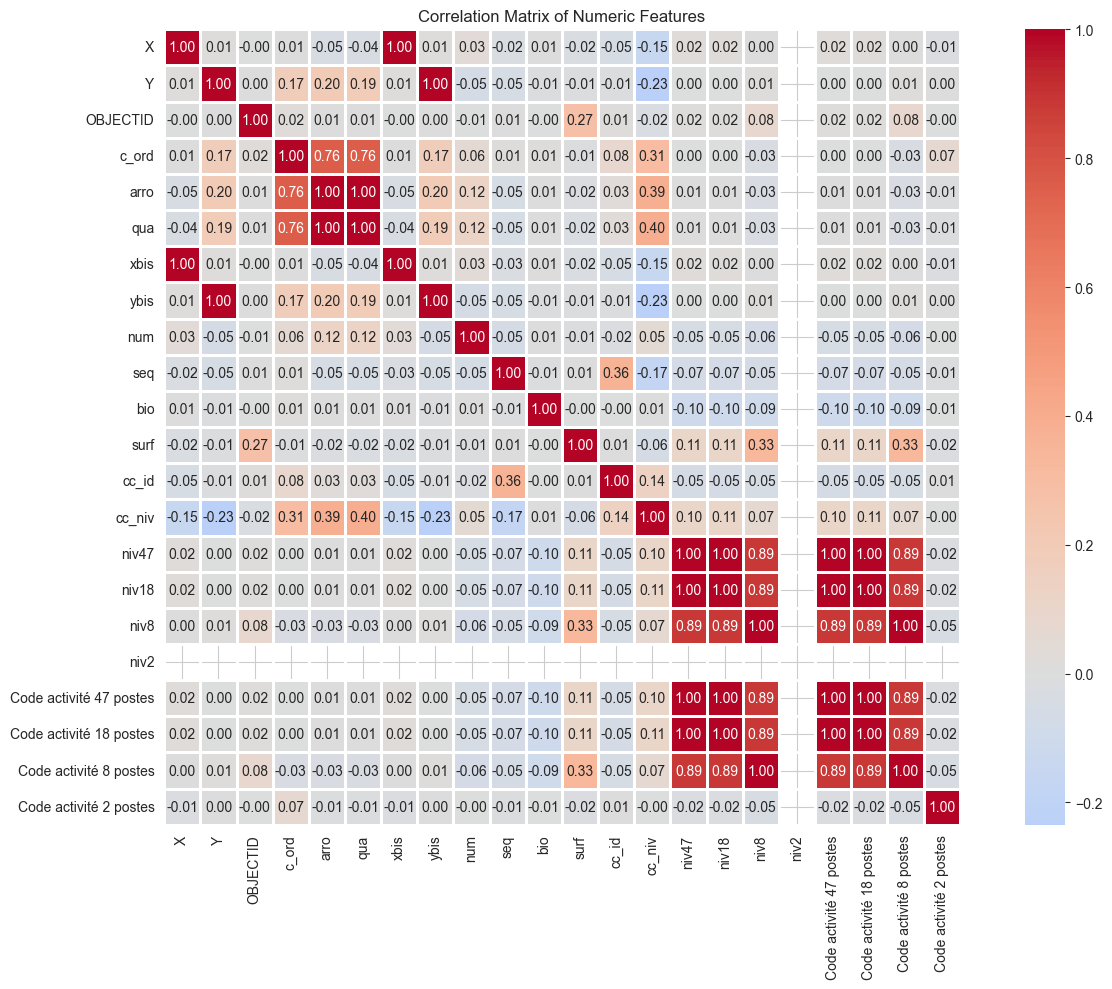

In [28]:
# Correlation matrix for numeric columns
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 1:
    correlation_matrix = df_merged[numeric_cols].corr()
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1)
    plt.title('Correlation Matrix of Numeric Features')
    plt.tight_layout()
    plt.show()

## 6. Data Cleaning

In [29]:
# Create a copy for cleaning
df_clean = df_merged.copy()

print("Starting data cleaning process...")
print(f"Initial shape: {df_clean.shape}")

Starting data cleaning process...
Initial shape: (60845, 37)


### 6.1 Remove Merge Indicator Column

In [30]:
# Drop the merge indicator column
if '_merge' in df_clean.columns:
    df_clean = df_clean.drop('_merge', axis=1)
    print("Dropped '_merge' indicator column")

Dropped '_merge' indicator column


### 6.2 Handle Duplicates

In [31]:
# Remove duplicate rows
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
rows_removed = initial_rows - len(df_clean)

print(f"Removed {rows_removed:,} duplicate rows")
print(f"Remaining rows: {len(df_clean):,}")

Removed 0 duplicate rows
Remaining rows: 60,845


### 6.3 Handle Missing Values

In [32]:
# Strategy for handling missing values:
# 1. For categorical columns with few missing values: fill with 'Unknown' or mode
# 2. For numeric columns: consider median or mean based on distribution
# 3. For columns with high missing percentage (>50%): consider dropping

missing_threshold = 50  # Drop columns with >50% missing

# Identify columns to drop
cols_to_drop = missing_data[missing_data['Missing_Percentage'] > missing_threshold]['Column'].tolist()

if cols_to_drop:
    print(f"\nDropping {len(cols_to_drop)} columns with >{missing_threshold}% missing values:")
    for col in cols_to_drop:
        print(f"  - {col}: {missing_data[missing_data['Column']==col]['Missing_Percentage'].values[0]:.2f}% missing")
    df_clean = df_clean.drop(cols_to_drop, axis=1)


Dropping 2 columns with >50% missing values:
  - let: 96.85% missing
  - cc_niv: 96.62% missing


In [33]:
# Fill missing values in remaining columns

# For 'let' (letter) column - fill with empty string
if 'let' in df_clean.columns:
    df_clean['let'].fillna('', inplace=True)
    print("Filled missing 'let' values with empty string")

# For 'cc_id' and 'cc_niv' - fill with 0 or appropriate default
for col in ['cc_id', 'cc_niv']:
    if col in df_clean.columns:
        df_clean[col].fillna(0, inplace=True)
        print(f"Filled missing '{col}' values with 0")

# For categorical activity columns - fill with 'Unknown'
categorical_activity_cols = ['Libellé activité (224 postes)', 'TYPE', 
                             'Libellé TYPE (local)', 'Libellé activité 47 postes',
                             'Libellé activité 18 postes', 'Libellé activité 8 postes)',
                             'Libellé activité 2 postes']

for col in categorical_activity_cols:
    if col in df_clean.columns and df_clean[col].isnull().any():
        df_clean[col].fillna('Unknown', inplace=True)
        print(f"Filled missing '{col}' values with 'Unknown'")

Filled missing 'cc_id' values with 0


### 6.4 Data Type Corrections

In [34]:
# Ensure proper data types

# Integer columns
int_cols = ['OBJECTID', 'c_ord', 'arro', 'qua', 'num', 'seq', 'bio', 'surf', 
            'cc_id', 'cc_niv', 'niv47', 'niv18', 'niv8', 'niv2',
            'Code activité 47 postes', 'Code activité 18 postes', 
            'Code activité 8 postes', 'Code activité 2 postes']

for col in int_cols:
    if col in df_clean.columns:
        try:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).astype(int)
        except:
            print(f"Could not convert {col} to integer")

# Float columns (coordinates)
float_cols = ['X', 'Y', 'xbis', 'ybis']
for col in float_cols:
    if col in df_clean.columns:
        try:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        except:
            print(f"Could not convert {col} to float")

print("\nData type corrections completed")


Data type corrections completed


### 6.5 String Data Cleaning

In [35]:
# Clean string columns: strip whitespace, standardize case where appropriate
string_cols = df_clean.select_dtypes(include=['object']).columns

for col in string_cols:
    # Strip whitespace
    df_clean[col] = df_clean[col].astype(str).str.strip()
    
    # Remove extra spaces
    df_clean[col] = df_clean[col].str.replace(r'\s+', ' ', regex=True)

print(f"Cleaned {len(string_cols)} string columns")

Cleaned 13 string columns


### 6.6 Outlier Detection and Handling

In [36]:
# Detect outliers using IQR method for numeric columns
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Check for outliers in surface area
if 'surf' in df_clean.columns:
    outlier_count, lower, upper = detect_outliers_iqr(df_clean, 'surf')
    print(f"\nOutliers in 'surf':")
    print(f"  Count: {outlier_count}")
    print(f"  Lower bound: {lower:.2f}")
    print(f"  Upper bound: {upper:.2f}")
    print(f"  Min value: {df_clean['surf'].min()}")
    print(f"  Max value: {df_clean['surf'].max()}")
    
    # Option: Cap outliers (uncomment if needed)
    # df_clean.loc[df_clean['surf'] < lower, 'surf'] = lower
    # df_clean.loc[df_clean['surf'] > upper, 'surf'] = upper


Outliers in 'surf':
  Count: 3280
  Lower bound: 1.00
  Upper bound: 1.00
  Min value: 1
  Max value: 3


### 6.7 Final Data Quality Check

In [37]:

print("FINAL DATA QUALITY REPORT")


print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Total rows: {len(df_clean):,}")
print(f"Total columns: {df_clean.shape[1]}")

# Missing values check
final_missing = df_clean.isnull().sum().sum()
print(f"\nTotal missing values: {final_missing:,}")

if final_missing > 0:
    print("\nColumns with remaining missing values:")
    remaining_missing = df_clean.isnull().sum()
    remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
    for col, count in remaining_missing.items():
        pct = (count / len(df_clean)) * 100
        print(f"  {col}: {count:,} ({pct:.2f}%)")

# Duplicates check
final_dupes = df_clean.duplicated().sum()
print(f"\nDuplicate rows: {final_dupes}")

# Data types
print("\nData types distribution:")
print(df_clean.dtypes.value_counts())

FINAL DATA QUALITY REPORT

Final dataset shape: (60845, 34)
Total rows: 60,845
Total columns: 34

Total missing values: 1

Columns with remaining missing values:
  ens: 1 (0.00%)

Duplicate rows: 0

Data types distribution:
int64      17
str        13
float64     4
Name: count, dtype: int64


In [38]:
# Display sample of cleaned data
print("CLEANED DATA SAMPLE")

display(df_clean.head(10))

CLEANED DATA SAMPLE


,X,Y,OBJECTID,c_ord,arro,qua,xbis,ybis,num,typ_voie,lib_voie,seq,sit,type,codact,ens,bio,surf,cc_id,niv47,niv18,niv8,niv2,Libellé activité (224 postes),TYPE,Libellé TYPE (local),Code activité 47 postes,Libellé activité 47 postes,Code activité 18 postes,Libellé activité 18 postes,Code activité 8 postes,Libellé activité 8 postes),Code activité 2 postes,Libellé activité 2 postes
0,651791.0486,6.862992e+06,1,1311,1,2,651792.345590,6.862996e+06,25,RUE,LOUVRE,2,A,C,CB107,Y'S,0,1,0,10301,103,3,1,Prêt-à-porter Mixte,C,Commerce,10301,Habillement,103,Equipement de la personne,3,Non Alimentaire,1,Commerce et service commercial
1,652152.0612,6.862579e+06,2,1464,1,2,652152.061200,6.862579e+06,1,RUE,PIERRE LESCOT,118,CC,C,CC301,ALAIN AFFLELOU,0,1,1,10403,104,3,1,Opticien,C,Commerce,10403,Opticien,104,Santé-Beauté,3,Non Alimentaire,1,Commerce et service commercial
2,651430.1357,6.862714e+06,4,1623,1,3,651430.135700,6.862714e+06,196,RUE,SAINT HONORE,1,R,C,CH106,ENZA FAMIGLIA,0,1,0,11101,111,5,1,Restaurant européen,C,Commerce,11101,Restauration traditionnelle,111,Café et Restaurant,5,Restauration,1,Commerce et service commercial
3,651133.4910,6.862932e+06,6,2087,1,3,651130.053214,6.862939e+06,7,RUE,ARGENTEUIL,3,R,C,SA202,JULIE BEAUTE,0,1,0,10802,108,4,1,Institut de beauté - Activités thermales et th...,C,Commerce,10802,Soins du corps,108,Service aux particuliers,4,Service commercial,1,Commerce et service commercial
4,651124.6132,6.863066e+06,7,2157,1,3,651124.613200,6.863066e+06,20,RUE,PYRAMIDES,1,A,C,CD201,HOME AUTOUR DU MONDE,0,1,0,10502,105,3,1,Equipement du foyer généraliste,C,Commerce,10502,Petit équipement du foyer,105,Equipement de la maison,3,Non Alimentaire,1,Commerce et service commercial
5,651177.3536,6.863106e+06,8,2174,1,3,651177.353600,6.863106e+06,22,AV,OPERA,1,R,C,CB202,FINSBURY,0,1,0,10302,103,3,1,Chaussures Homme,C,Commerce,10302,Chaussures et Maroquinerie,103,Equipement de la personne,3,Non Alimentaire,1,Commerce et service commercial
6,651287.7409,6.862999e+06,10,2194,1,3,651287.740900,6.862999e+06,15,RUE,MOLIERE,1,R,C,SA102,DIAMANT COUTURE,0,1,0,10801,108,4,1,Retouches de vêtements,C,Commerce,10801,Service liés à l'équipement de la personne,108,Service aux particuliers,4,Service commercial,1,Commerce et service commercial
7,651221.5991,6.863215e+06,11,2310,1,3,651221.599100,6.863215e+06,51,RUE,PETITS CHAMPS,1,A,C,CC301,LARRY OPTICIENS,0,1,0,10403,104,3,1,Opticien,C,Commerce,10403,Opticien,104,Santé-Beauté,3,Non Alimentaire,1,Commerce et service commercial
8,650988.6165,6.862949e+06,12,2405,1,3,650988.616500,6.862949e+06,16,RUE,SAINT ROCH,1,R,C,CB105,CIFONELLI,0,1,0,10301,103,3,1,Prêt-à-porter Homme,C,Commerce,10301,Habillement,103,Equipement de la personne,3,Non Alimentaire,1,Commerce et service commercial
9,650959.5176,6.863140e+06,14,2522,1,4,650959.517600,6.863140e+06,14,RUE,MARCHE SAINT HONORE,1,A,C,CH106,NOMAD'S,0,1,0,11101,111,5,1,Restaurant européen,C,Commerce,11101,Restauration traditionnelle,111,Café et Restaurant,5,Restauration,1,Commerce et service commercial


## 7. Save Cleaned Data

In [50]:
# Save to CSV
output_csv = output_path / "BDCOM_2023_merged_cleaned.csv"
df_clean.to_csv(output_csv, index=False, encoding="utf-8-sig")
print(f"Cleaned data saved to: {output_csv}")

Cleaned data saved to: C:\Users\annan\Desktop\Quang Dat Doc\EFREI\DataSCience\Project-urban-data-explorer\data\silver\BDCOM_2023_merged_cleaned.csv
Cleaned data saved to: C:\Users\annan\Desktop\Quang Dat Doc\EFREI\DataSCience\Project-urban-data-explorer\data\silver\BDCOM_2023_merged_cleaned.xlsx


## 8. Summary Statistics of Cleaned Data

In [40]:
# Generate comprehensive summary

print("CLEANED DATA SUMMARY")


summary_stats = {
    'Metric': [
        'Total Records',
        'Total Features',
        'Numeric Features',
        'Categorical Features',
        'Missing Values',
        'Duplicate Rows',
        'Memory Usage (MB)'
    ],
    'Value': [
        f"{len(df_clean):,}",
        df_clean.shape[1],
        len(df_clean.select_dtypes(include=[np.number]).columns),
        len(df_clean.select_dtypes(include=['object']).columns),
        f"{df_clean.isnull().sum().sum():,}",
        df_clean.duplicated().sum(),
        f"{df_clean.memory_usage(deep=True).sum() / 1024**2:.2f}"
    ]
}

summary_df = pd.DataFrame(summary_stats)
display(summary_df)

CLEANED DATA SUMMARY


,Metric,Value
0,Total Records,"60,845"
1,Total Features,34
2,Numeric Features,21
3,Categorical Features,13
4,Missing Values,1
5,Duplicate Rows,0
6,Memory Usage (MB),59.01


In [41]:
# Activity distribution summary
if 'Libellé activité 8 postes)' in df_clean.columns:
    print("\n" + "=" * 80)
    print("ACTIVITY DISTRIBUTION (8 CATEGORIES)")
    
    activity_dist = df_clean['Libellé activité 8 postes)'].value_counts()
    activity_df = pd.DataFrame({
        'Activity': activity_dist.index,
        'Count': activity_dist.values,
        'Percentage': (activity_dist.values / activity_dist.sum() * 100).round(2)
    })
    display(activity_df)


ACTIVITY DISTRIBUTION (8 CATEGORIES)


,Activity,Count,Percentage
0,Non Alimentaire,20566,33.80
1,Service commercial,17557,28.86
2,Restauration,12013,19.74
3,Alimentaire,8252,13.56
4,Hôtel,1874,3.08
5,Autre local,406,0.67
6,Grand magasin,177,0.29
